In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats
from scipy.stats import zscore

In [2]:
# Load dataset
df = pd.read_csv('../data/sierraleone-bumbuna.csv')

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-nul

In [3]:
df.describe()
df.isna().sum()
(df.isna().sum()/len(df))*100  # % nulls

Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64

In [4]:
cols = ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']
z_scores = np.abs(stats.zscore(df[cols]))
outliers = (z_scores > 3)
num_outliers = outliers.sum().sum()
print(f"Number of outlier rows: {num_outliers}")

Number of outlier rows: 24326


In [5]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())
    lower, upper = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower, upper)

In [6]:
df.to_csv('../data/sierraleone_clean.csv', index=False)

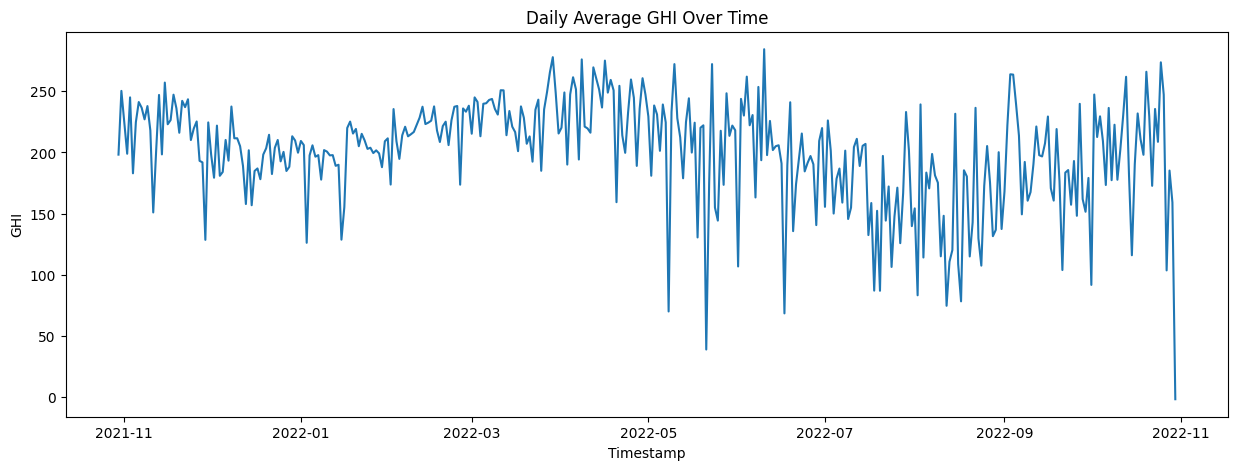

In [7]:

# Time-series analysis

# plt.figure(figsize=(15,5))
# sns.lineplot(x='Timestamp', y='GHI', data=df)
# plt.title('GHI Over Time')
# plt.show()
# Resample to hourly or daily averages
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

# Daily average
df_daily = df.resample('D').mean().reset_index()

# Plot daily GHI
plt.figure(figsize=(15,5))
sns.lineplot(x='Timestamp', y='GHI', data=df_daily)
plt.title('Daily Average GHI Over Time')
plt.show()

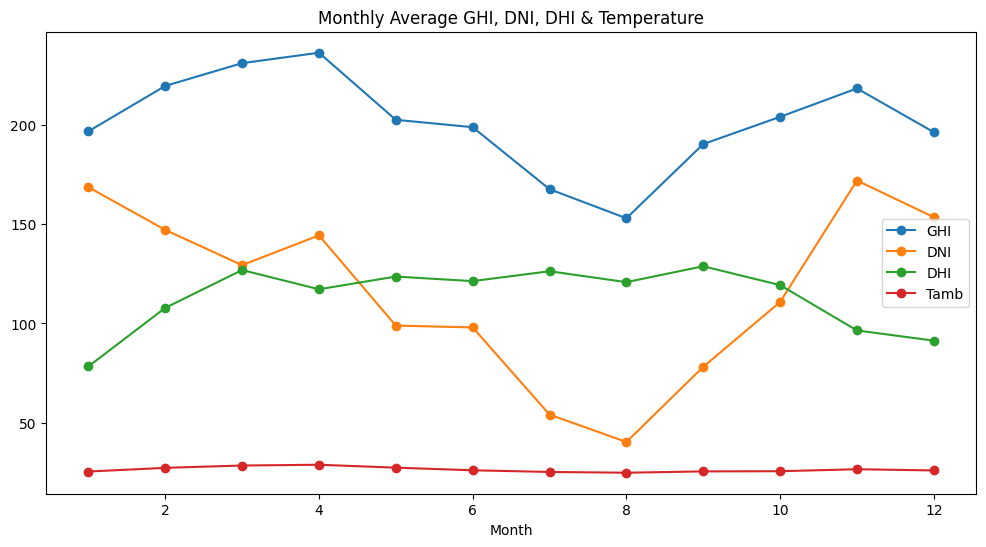

In [9]:
df['Month'] = df.index.month
monthly_avg = df.groupby('Month')[['GHI','DNI','DHI','Tamb']].mean()
monthly_avg.plot(kind='line', marker='o', figsize=(12,6))
plt.title('Monthly Average GHI, DNI, DHI & Temperature')
plt.show()


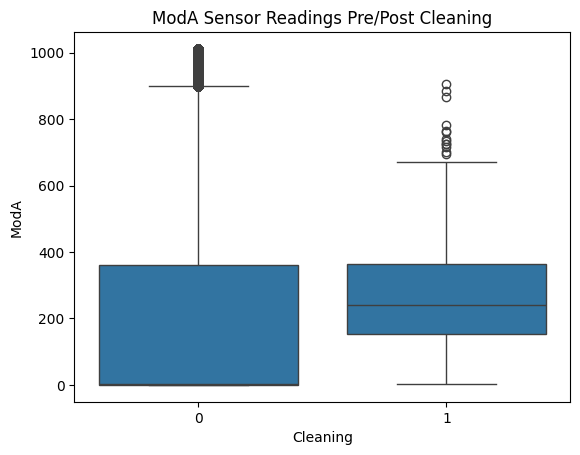

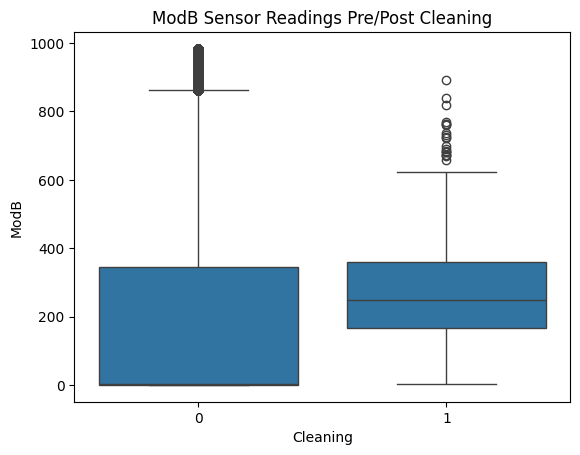

In [10]:
# ModA & ModB Cleaning
sns.boxplot(x='Cleaning', y='ModA', data=df)
plt.title('ModA Sensor Readings Pre/Post Cleaning')
plt.show()

sns.boxplot(x='Cleaning', y='ModB', data=df)
plt.title('ModB Sensor Readings Pre/Post Cleaning')
plt.show()

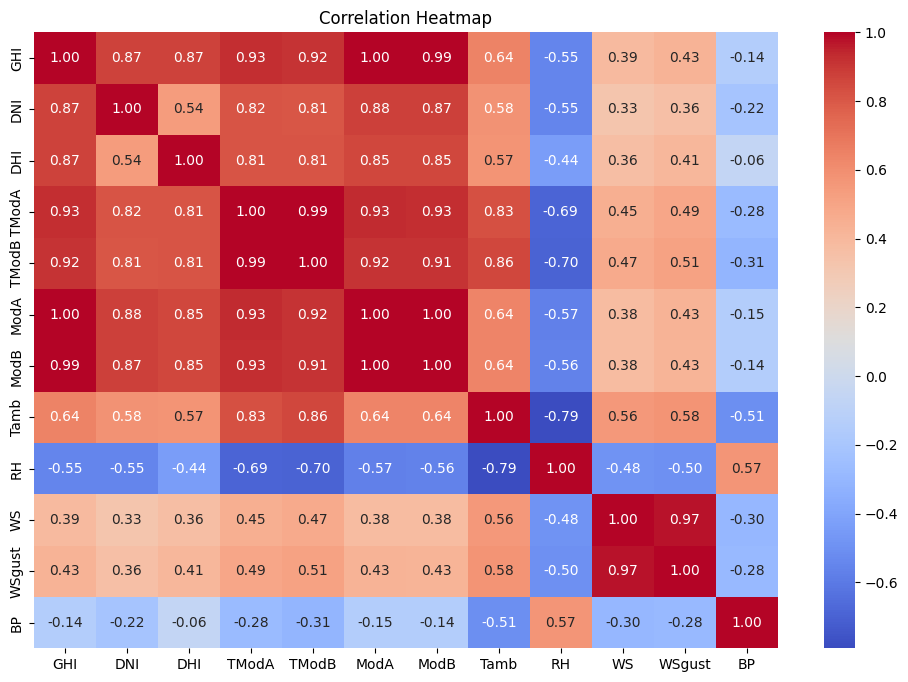

In [11]:

# Correlation & scatter plots

corr_cols = ['GHI','DNI','DHI','TModA','TModB','ModA','ModB','Tamb','RH','WS','WSgust','BP']
plt.figure(figsize=(12,8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



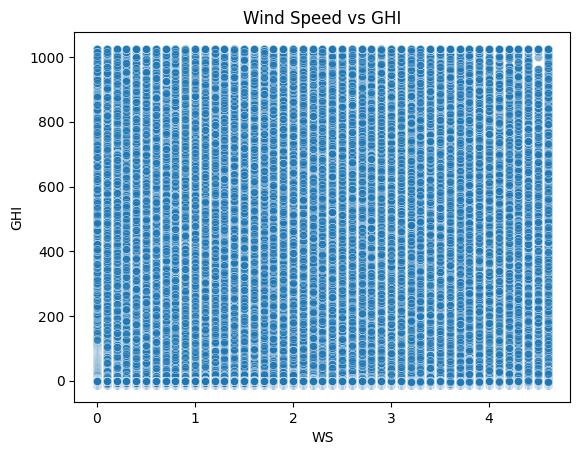

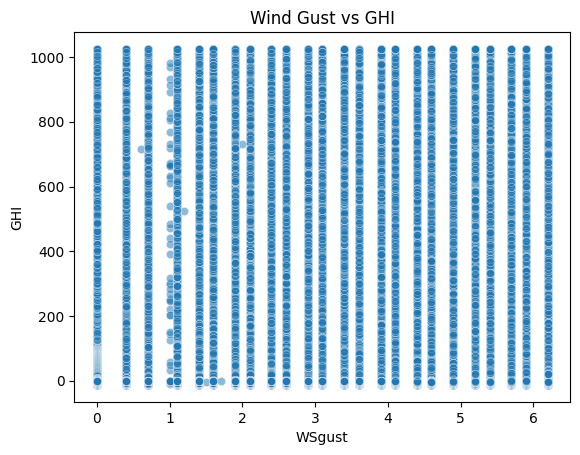

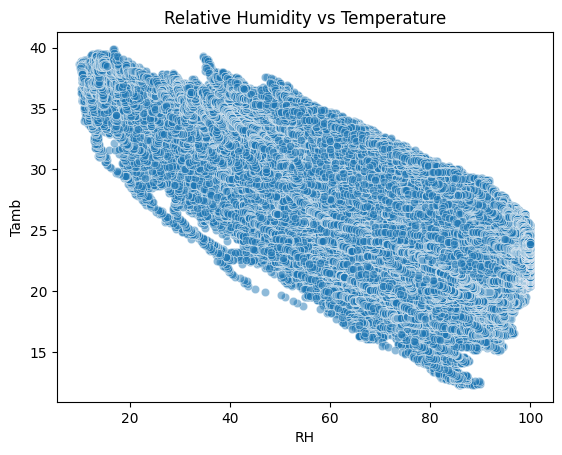

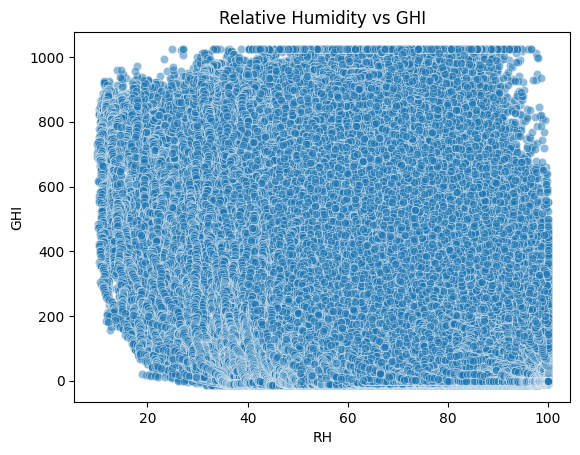

In [12]:
# Scatter plots
sns.scatterplot(data=df, x='WS', y='GHI', alpha=0.5)
plt.title('Wind Speed vs GHI')
plt.show()

sns.scatterplot(data=df, x='WSgust', y='GHI', alpha=0.5)
plt.title('Wind Gust vs GHI')
plt.show()

sns.scatterplot(data=df, x='RH', y='Tamb', alpha=0.5)
plt.title('Relative Humidity vs Temperature')
plt.show()

sns.scatterplot(data=df, x='RH', y='GHI', alpha=0.5)
plt.title('Relative Humidity vs GHI')
plt.show()


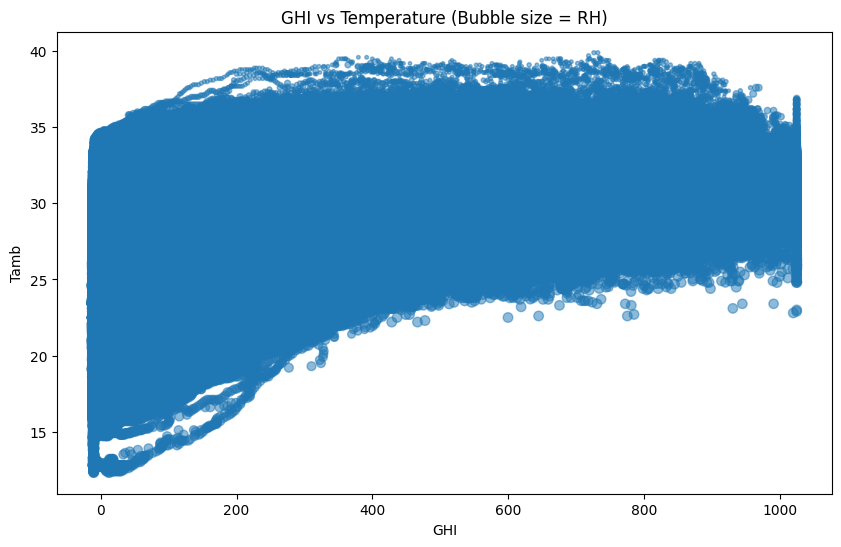

In [13]:

# Bubble chart
plt.figure(figsize=(10,6))
plt.scatter(df['GHI'], df['Tamb'], s=df['RH']/2, alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Tamb')
plt.title('GHI vs Temperature (Bubble size = RH)')
plt.show()

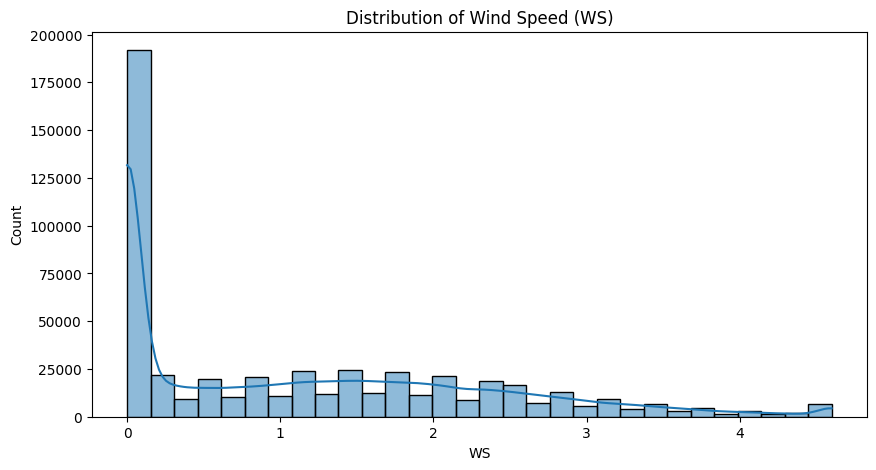

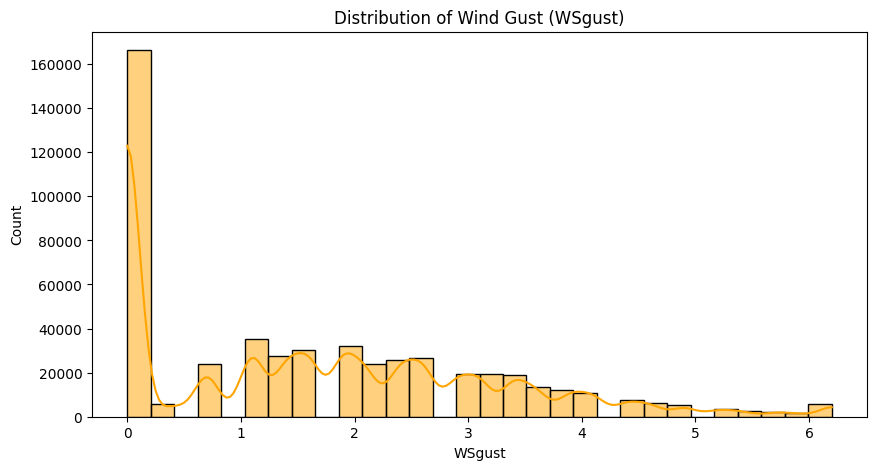

In [14]:
#Wind & distribution analysis

plt.figure(figsize=(10,5))
sns.histplot(df['WS'], bins=30, kde=True)
plt.title('Distribution of Wind Speed (WS)')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['WSgust'], bins=30, kde=True, color='orange')
plt.title('Distribution of Wind Gust (WSgust)')
plt.show()


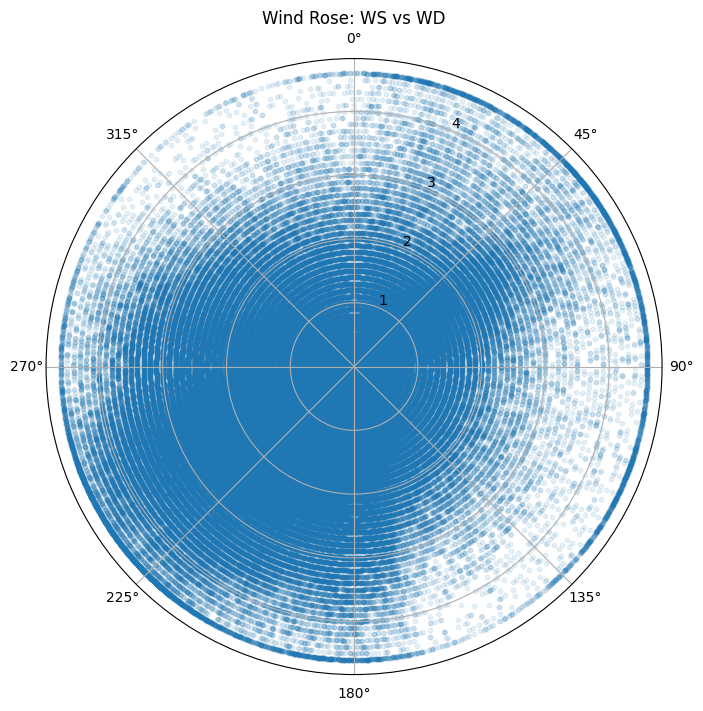

In [15]:
# Wind rose
theta = np.deg2rad(df['WD'])
r = df['WS']
plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)
ax.scatter(theta, r, alpha=0.1, s=10)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.title('Wind Rose: WS vs WD')
plt.show()



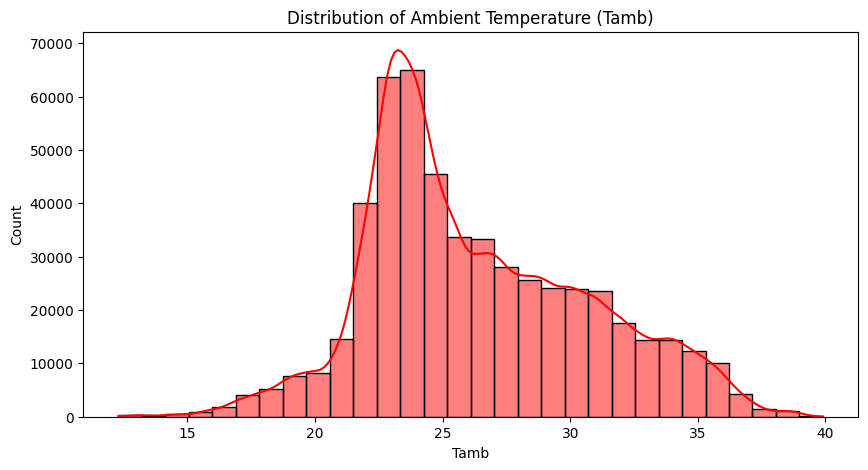

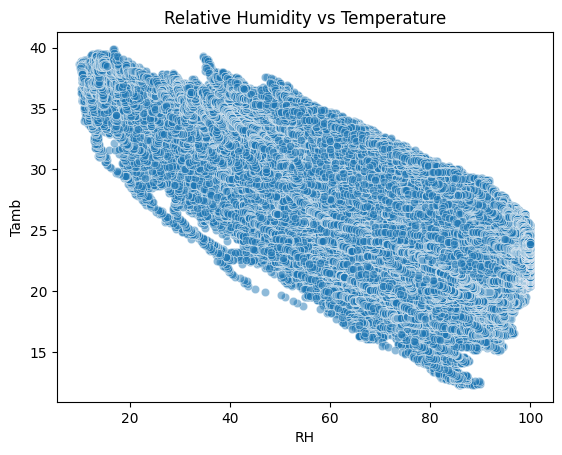

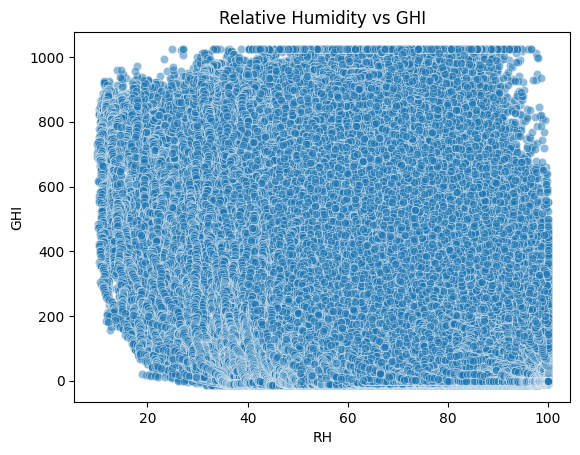

In [16]:
#Temperature analysis

plt.figure(figsize=(10,5))
sns.histplot(df['Tamb'], bins=30, kde=True, color='red')
plt.title('Distribution of Ambient Temperature (Tamb)')
plt.show()

sns.scatterplot(data=df, x='RH', y='Tamb', alpha=0.5)
plt.title('Relative Humidity vs Temperature')
plt.show()

sns.scatterplot(data=df, x='RH', y='GHI', alpha=0.5)
plt.title('Relative Humidity vs GHI')
plt.show()